<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Kalyani_khkval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df= pd.read_excel('/content/Dr Kalyani thesis KH_KV_AL training data cleaned.xlsx')


In [ ]:
df.shape

(2001, 3)

In [ ]:
df.columns

Index(['KH', 'KV', 'AL(actual)'], dtype='object')

In [ ]:
df.corr()

,KH,KV,AL(actual)
KH,1.000000,0.788555,-0.228958
KV,0.788555,1.000000,-0.200976
AL(actual),-0.228958,-0.200976,1.000000


In [ ]:
# prompt: Remove outliers in AL(actual)

def remove_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].copy()
  return df_cleaned

df_cleaned = remove_outliers_iqr(df, 'AL(actual)')

print("Original shape:", df.shape)
print("Shape after removing outliers in 'AL(actual)':", df_cleaned.shape)


Original shape: (2001, 3)
Shape after removing outliers in 'AL(actual)': (1965, 3)


In [ ]:
df_cleaned.corr()

,KH,KV,AL(actual)
KH,1.000000,0.789008,-0.245095
KV,0.789008,1.000000,-0.215164
AL(actual),-0.245095,-0.215164,1.000000


<Axes: >

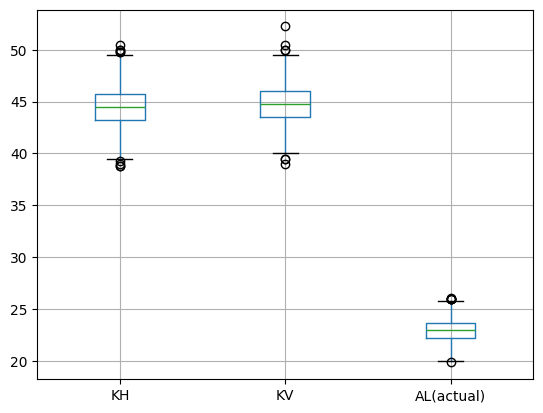

In [ ]:
df_cleaned.boxplot()

Shape after removing outliers in 'KH' and 'KV': (1949, 3)


<Axes: >

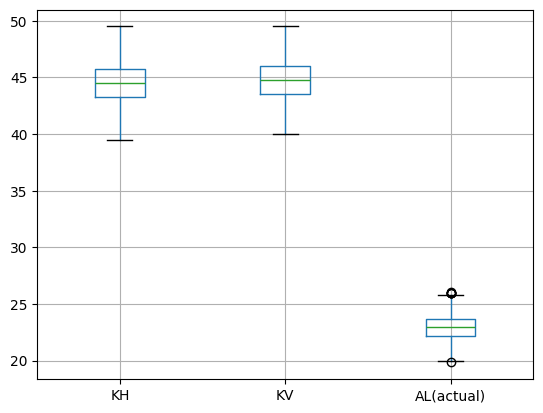

In [ ]:
# prompt: Remove outliers in KH and KV also

df_cleaned = remove_outliers_iqr(df_cleaned, 'KH')
df_cleaned = remove_outliers_iqr(df_cleaned, 'KV')

print("Shape after removing outliers in 'KH' and 'KV':", df_cleaned.shape)

df_cleaned.corr()
df_cleaned.boxplot()


Shape after removing outliers again in 'AL(actual)': (1942, 3)


<Axes: >

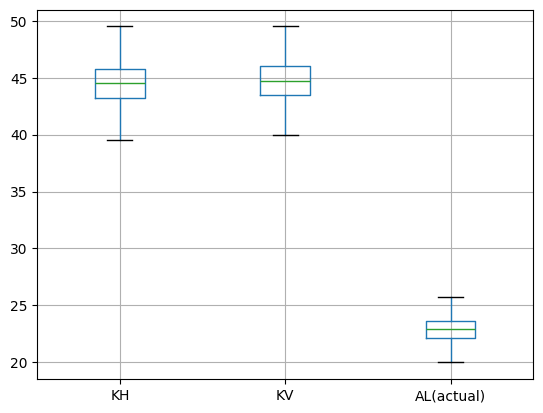

In [ ]:
# prompt: Remove outliers in AL

df_cleaned = remove_outliers_iqr(df_cleaned, 'AL(actual)')

print("Shape after removing outliers again in 'AL(actual)':", df_cleaned.shape)

df_cleaned.corr()
df_cleaned.boxplot()

In [ ]:
df_cleaned.shape

(1942, 3)

In [ ]:
df_cleaned.corr()

,KH,KV,AL(actual)
KH,1.000000,0.793381,-0.238289
KV,0.793381,1.000000,-0.212662
AL(actual),-0.238289,-0.212662,1.000000


Mean Squared Error: 0.9496384668236305
R-squared: 0.07470245161239408
Coefficients: [-0.09319395 -0.05180426]
Intercept: 29.3986925201633


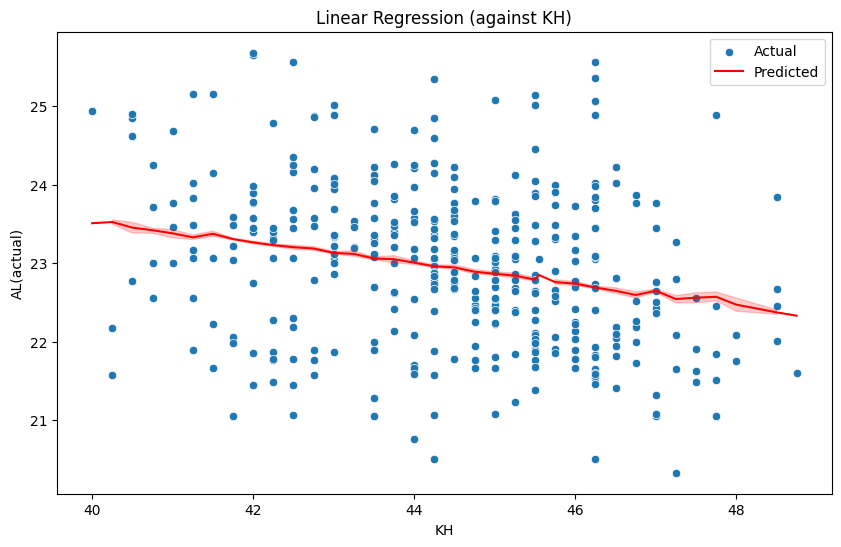

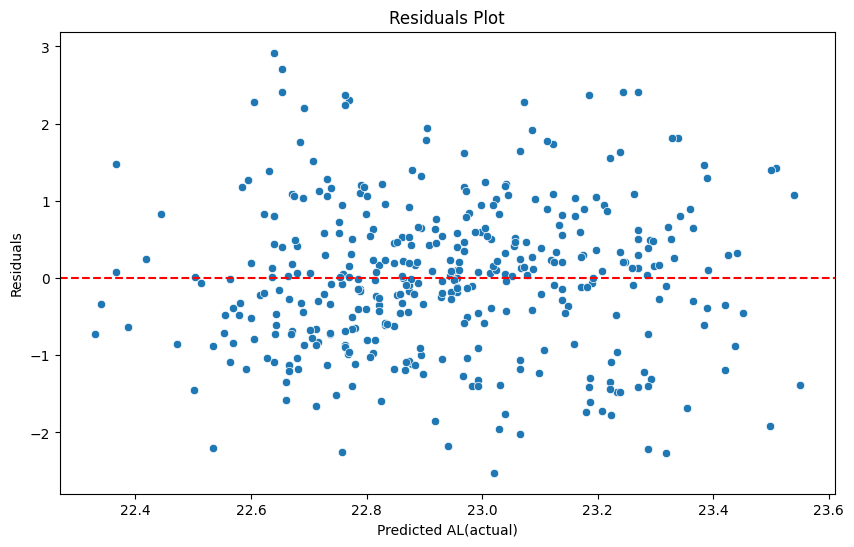

In [ ]:
# prompt: Linear regression

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y)
# Assuming 'KH' and 'KV' are features and 'AL(actual)' is the target
X = df_cleaned[['KH', 'KV']]
y = df_cleaned['AL(actual)']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model (optional)
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Display the model coefficients and intercept
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

# Optional: Plotting the results (for a single feature for visualization)
# If you want to visualize with two features, a 3D plot would be needed.
# Let's plot against one feature, e.g., 'KH'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['KH'], y=y_test, label='Actual')
sns.lineplot(x=X_test['KH'], y=y_pred, color='red', label='Predicted') # This is a simplification for visualization, not the actual linear plane
plt.title('Linear Regression (against KH)')
plt.xlabel('KH')
plt.ylabel('AL(actual)')
plt.legend()
plt.show()

# You can also plot the residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Predicted AL(actual)')
plt.ylabel('Residuals')
plt.show()


--- SVR Model Evaluation ---
Mean Squared Error (SVR): 0.9858424023007466
R-squared (SVR): 0.03942648722248476


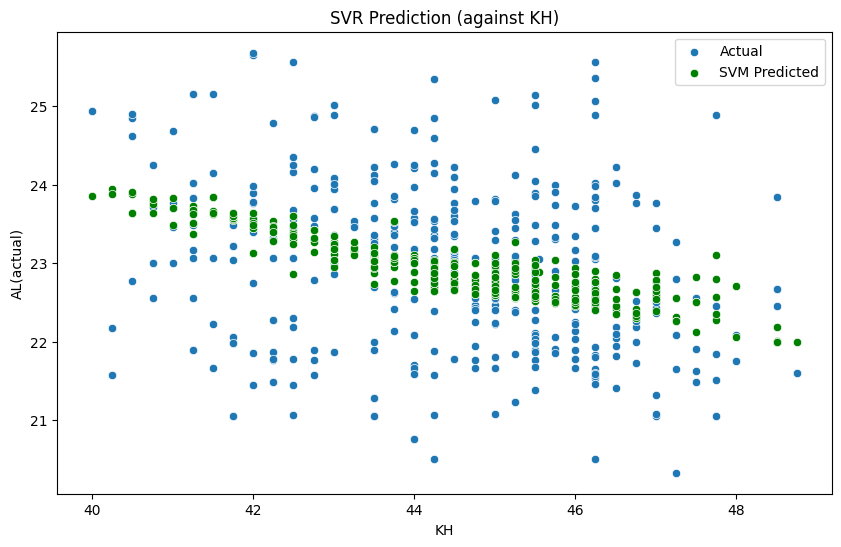

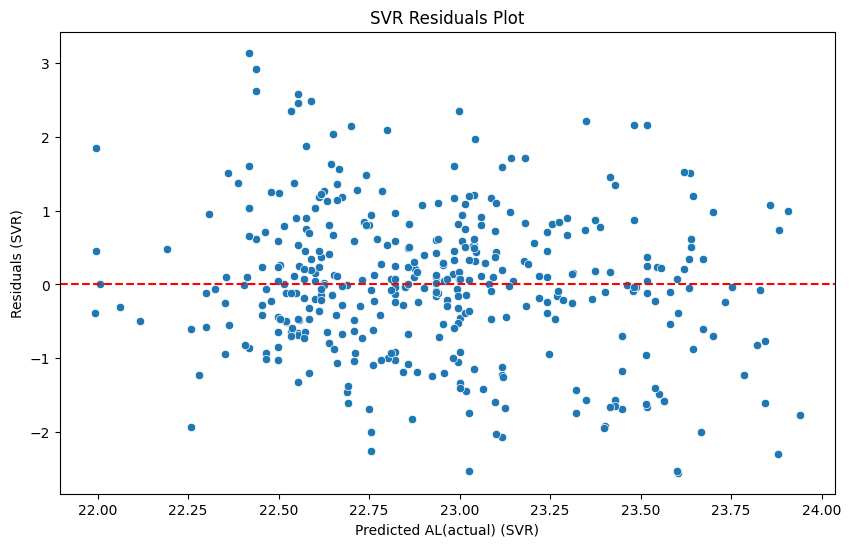

In [ ]:
# prompt: Svm

import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Create an SVR model
# You can choose different kernels like 'linear', 'poly', 'rbf' (default)
# and adjust parameters like C, epsilon, gamma
# For example, using the default 'rbf' kernel
svm_model = SVR(kernel='rbf')

# Train the SVR model
svm_model.fit(X_train, y_train)

# Make predictions using the SVR model
y_pred_svm = svm_model.predict(X_test)

# Evaluate the SVR model
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("\n--- SVR Model Evaluation ---")
print(f"Mean Squared Error (SVR): {mse_svm}")
print(f"R-squared (SVR): {r2_svm}")

# Optional: Plotting the results for SVR (against one feature for visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['KH'], y=y_test, label='Actual')
sns.scatterplot(x=X_test['KH'], y=y_pred_svm, color='green', label='SVM Predicted') # Use scatter for SVR prediction points
plt.title('SVR Prediction (against KH)')
plt.xlabel('KH')
plt.ylabel('AL(actual)')
plt.legend()
plt.show()

# Plotting SVR residuals
residuals_svm = y_test - y_pred_svm
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_svm, y=residuals_svm)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('SVR Residuals Plot')
plt.xlabel('Predicted AL(actual) (SVR)')
plt.ylabel('Residuals (SVR)')
plt.show()


--- XGBoost Model Evaluation ---
Mean Squared Error (XGBoost): 0.9762930308607721
R-squared (XGBoost): 0.04873109133314779


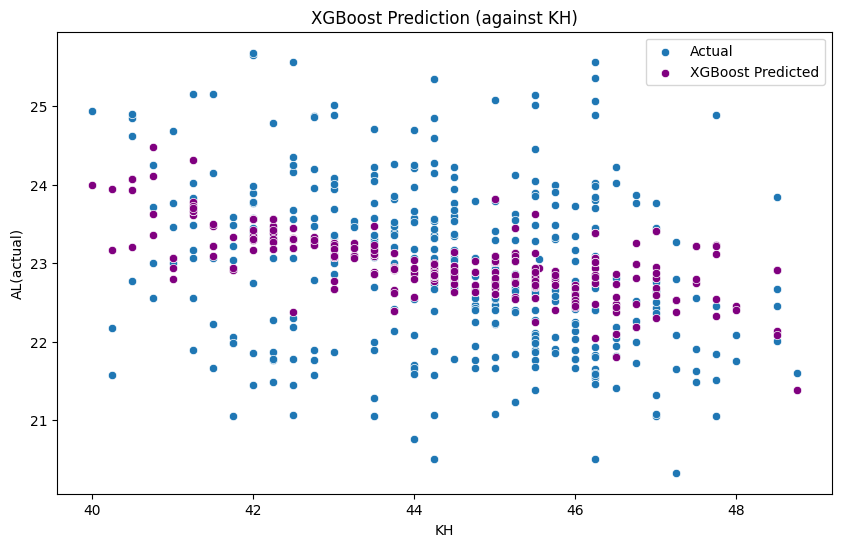

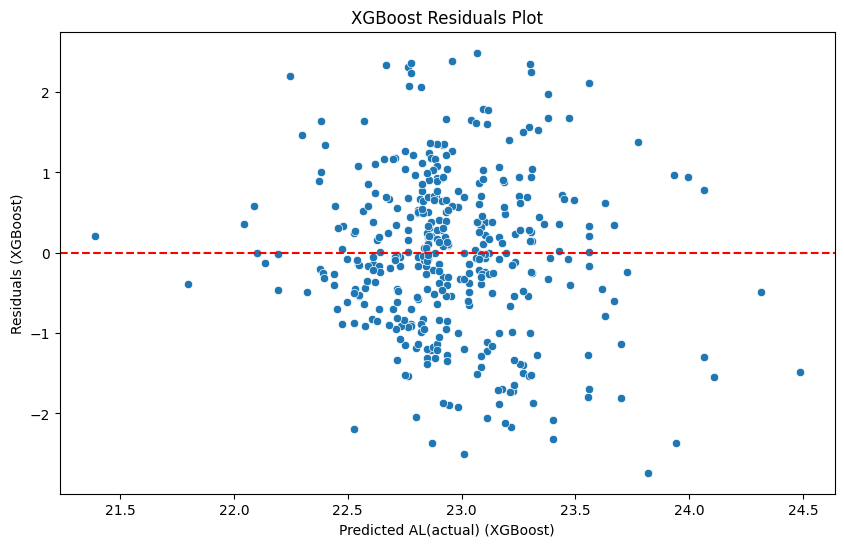

<Figure size 1000x600 with 0 Axes>

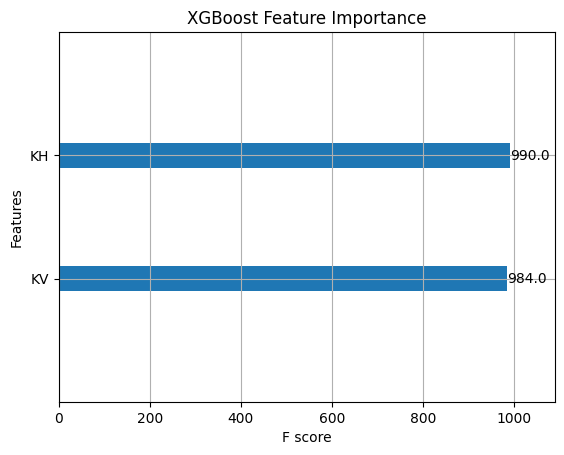

In [ ]:
# prompt: XGboost

import matplotlib.pyplot as plt
!pip install xgboost

import xgboost as xgb

# Create an XGBoost Regressor model
# You can tune parameters like n_estimators, learning_rate, max_depth, etc.
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', # Regression task
                             n_estimators=100,          # Number of boosting rounds
                             learning_rate=0.1,         # Step size shrinkage
                             max_depth=5,               # Maximum depth of a tree
                             random_state=42)           # For reproducibility

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

# Make predictions using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the XGBoost model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n--- XGBoost Model Evaluation ---")
print(f"Mean Squared Error (XGBoost): {mse_xgb}")
print(f"R-squared (XGBoost): {r2_xgb}")

# Optional: Plotting the results for XGBoost (against one feature for visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['KH'], y=y_test, label='Actual')
sns.scatterplot(x=X_test['KH'], y=y_pred_xgb, color='purple', label='XGBoost Predicted') # Use scatter for prediction points
plt.title('XGBoost Prediction (against KH)')
plt.xlabel('KH')
plt.ylabel('AL(actual)')
plt.legend()
plt.show()

# Plotting XGBoost residuals
residuals_xgb = y_test - y_pred_xgb
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_xgb, y=residuals_xgb)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('XGBoost Residuals Plot')
plt.xlabel('Predicted AL(actual) (XGBoost)')
plt.ylabel('Residuals (XGBoost)')
plt.show()

# You can also visualize feature importances
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, importance_type='weight') # 'weight', 'gain', 'cover'
plt.title('XGBoost Feature Importance')
plt.show()


--- RFE Feature Selection ---
Selected features by RFE (n_features=1): Index(['KH'], dtype='object')
Feature rankings: [1 2]
Support (mask): [ True False]

--- Linear Regression Cross-Validation ---
Mean MSE (CV): 0.9924 (+/- 0.0492)
Mean R-squared (CV): 0.0525 (+/- 0.0244)

--- SVR Cross-Validation ---
Mean MSE (SVR CV): 1.0256 (+/- 0.0686)
Mean R-squared (SVR CV): 0.0213 (+/- 0.0419)

--- XGBoost Cross-Validation ---
Mean MSE (XGBoost CV): 1.0705 (+/- 0.0782)
Mean R-squared (XGBoost CV): -0.0215 (+/- 0.0503)

--- Model Comparison Summary (Mean CV Scores) ---
Linear Regression: MSE = 0.9924, R2 = 0.0525
SVR:               MSE = 1.0256, R2 = 0.0213
XGBoost:           MSE = 1.0705, R2 = -0.0215


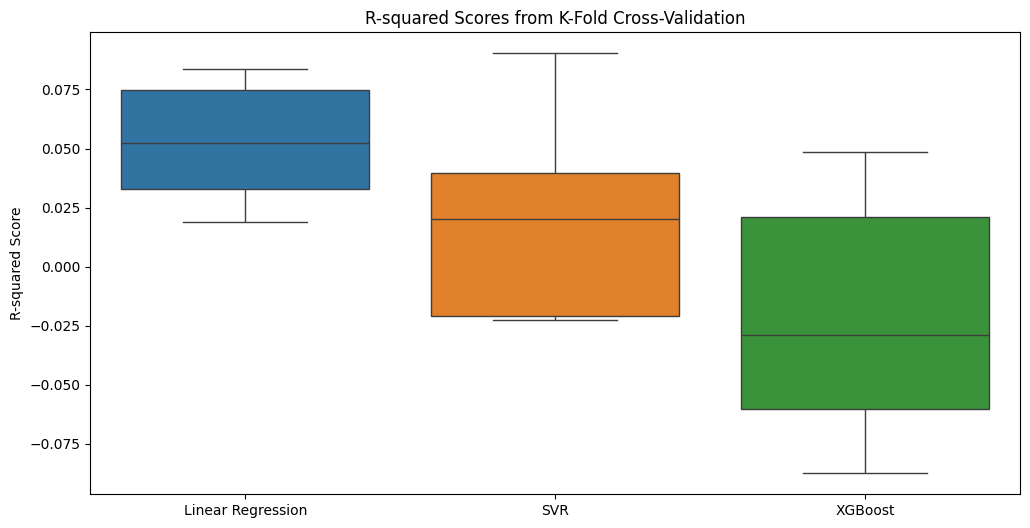

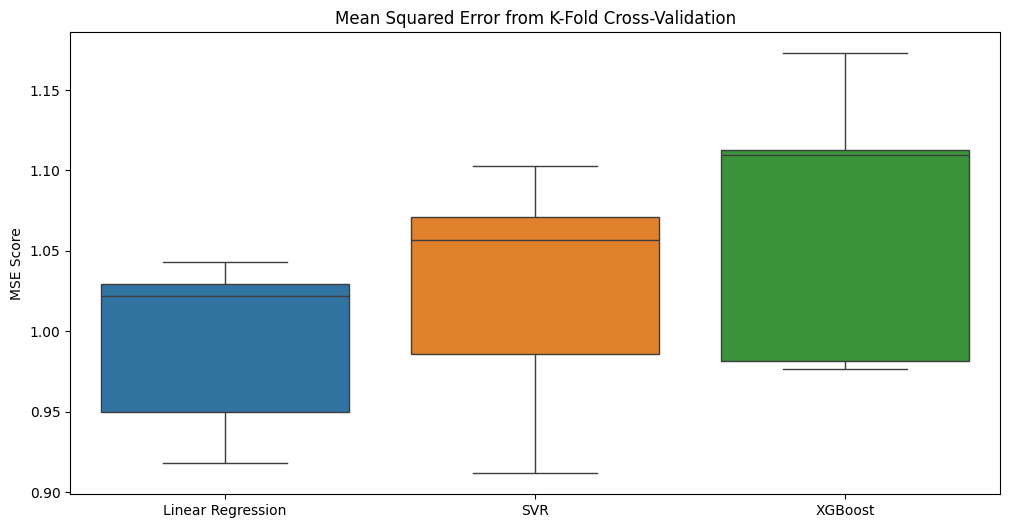

In [ ]:
# prompt: Improve R

import pandas as pd
import matplotlib.pyplot as plt
# The previous code block already has the imports and data loading/cleaning.
# We will now add the RFE part and cross-validation.

from sklearn.feature_selection import RFE
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled X back to DataFrame to keep column names for RFE
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# --- Feature Selection using Recursive Feature Elimination (RFE) ---
# Let's use RFE with the Linear Regression model to select the best features.
# Since we only have 2 features ('KH', 'KV'), RFE here will show if one is preferred.
# If you had many features, this would be more impactful.

# Create the RFE object and specify the number of features to select (e.g., 1 or 2)
# Let's try selecting 1 feature
rfe = RFE(estimator=LinearRegression(), n_features_to_select=1)

# Fit RFE on the scaled training data (or the full scaled data before splitting)
# Fitting on the full data first is common for initial feature selection
rfe.fit(X_scaled_df, y)

# Get the selected features
selected_features_rfe = X_scaled_df.columns[rfe.support_]

print("\n--- RFE Feature Selection ---")
print(f"Selected features by RFE (n_features=1): {selected_features_rfe}")

# We can also check the ranking
print("Feature rankings:", rfe.ranking_)
print("Support (mask):", rfe.support_)

# Based on RFE, if 'KH' was ranked 1 and 'KV' was ranked 2, it suggests 'KH' is more important
# If both are selected (n_features_to_select=2), it means both are considered important.
# Since we only have two, and both are likely relevant, we will continue using both
# 'KH' and 'KV' for model training. RFE would be more critical with a larger feature set.

# Let's update X based on RFE results if needed, but here we stick to both for demonstration
# X_selected = X[selected_features_rfe]
# X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


# --- Cross-Validation ---
# Use K-Fold cross-validation to get a more robust estimate of model performance.
# This is important to ensure the performance isn't just lucky on one split.

# Define the number of folds
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Evaluate Linear Regression using cross-validation
print("\n--- Linear Regression Cross-Validation ---")
lr_scores_mse = -cross_val_score(LinearRegression(), X_scaled, y, cv=kf, scoring='neg_mean_squared_error') # cv=kf applies KFold
lr_scores_r2 = cross_val_score(LinearRegression(), X_scaled, y, cv=kf, scoring='r2')

print(f"Mean MSE (CV): {lr_scores_mse.mean():.4f} (+/- {lr_scores_mse.std():.4f})")
print(f"Mean R-squared (CV): {lr_scores_r2.mean():.4f} (+/- {lr_scores_r2.std():.4f})")

# Evaluate SVR using cross-validation (using the same parameters as before)
print("\n--- SVR Cross-Validation ---")
svm_scores_mse = -cross_val_score(SVR(kernel='rbf'), X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
svm_scores_r2 = cross_val_score(SVR(kernel='rbf'), X_scaled, y, cv=kf, scoring='r2')

print(f"Mean MSE (SVR CV): {svm_scores_mse.mean():.4f} (+/- {svm_scores_mse.std():.4f})")
print(f"Mean R-squared (SVR CV): {svm_scores_r2.mean():.4f} (+/- {svm_scores_r2.std():.4f})")

# Evaluate XGBoost using cross-validation (using the same parameters as before)
print("\n--- XGBoost Cross-Validation ---")
xgb_scores_mse = -cross_val_score(xgb.XGBRegressor(objective='reg:squarederror',
                                                 n_estimators=100,
                                                 learning_rate=0.1,
                                                 max_depth=5,
                                                 random_state=42),
                                 X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
xgb_scores_r2 = cross_val_score(xgb.XGBRegressor(objective='reg:squarederror',
                                               n_estimators=100,
                                               learning_rate=0.1,
                                               max_depth=5,
                                               random_state=42),
                               X_scaled, y, cv=kf, scoring='r2')

print(f"Mean MSE (XGBoost CV): {xgb_scores_mse.mean():.4f} (+/- {xgb_scores_mse.std():.4f})")
print(f"Mean R-squared (XGBoost CV): {xgb_scores_r2.mean():.4f} (+/- {xgb_scores_r2.std():.4f})")


# --- Summary and Model Comparison ---
# You can now compare the mean cross-validation scores for each model.
# A lower mean MSE and a higher mean R-squared indicate better performance on average
# across different subsets of the data.

print("\n--- Model Comparison Summary (Mean CV Scores) ---")
print(f"Linear Regression: MSE = {lr_scores_mse.mean():.4f}, R2 = {lr_scores_r2.mean():.4f}")
print(f"SVR:               MSE = {svm_scores_mse.mean():.4f}, R2 = {svm_scores_r2.mean():.4f}")
print(f"XGBoost:           MSE = {xgb_scores_mse.mean():.4f}, R2 = {xgb_scores_r2.mean():.4f}")

# Based on these scores, you can decide which model performs best on this dataset.
# Further steps could include:
# 1. Hyperparameter tuning for the best performing model(s) using GridSearchCV or RandomizedSearchCV.
# 2. Exploring other models (e.g., RandomForestRegressor, Ridge, Lasso).
# 3. Investigating feature engineering or interaction terms.
# 4. Checking assumptions of the chosen model.
# 5. Visualizing actual vs. predicted values for the test set of the best model.

# Let's visualize the performance comparison using boxplots of the CV scores
results_r2 = pd.DataFrame({
    'Linear Regression': lr_scores_r2,
    'SVR': svm_scores_r2,
    'XGBoost': xgb_scores_r2
})

plt.figure(figsize=(12, 6))
sns.boxplot(data=results_r2)
plt.title('R-squared Scores from K-Fold Cross-Validation')
plt.ylabel('R-squared Score')
plt.show()

results_mse = pd.DataFrame({
    'Linear Regression': lr_scores_mse,
    'SVR': svm_scores_mse,
    'XGBoost': xgb_scores_mse
})

plt.figure(figsize=(12, 6))
sns.boxplot(data=results_mse)
plt.title('Mean Squared Error from K-Fold Cross-Validation')
plt.ylabel('MSE Score')
plt.show()


In [ ]:
# prompt: OLS

import statsmodels.api as sm

# Add a constant (intercept) term to the features for statsmodels
X_train_sm = sm.add_constant(X_train)

# Create and fit the OLS model using statsmodels
sm_model = sm.OLS(y_train, X_train_sm)
results = sm_model.fit()

# Print the summary table
print("\n--- Statsmodels OLS Summary ---")
print(results.summary())

# You can also get predictions on the test set using the statsmodels model
# Need to add constant to test features as well
X_test_sm = sm.add_constant(X_test)
y_pred_sm = results.predict(X_test_sm)

# Evaluate the statsmodels predictions (should be very similar to sklearn's)
mse_sm = mean_squared_error(y_test, y_pred_sm)
r2_sm = r2_score(y_test, y_pred_sm)

print("\n--- Statsmodels OLS Evaluation on Test Set ---")
print(f"Mean Squared Error (Statsmodels OLS): {mse_sm}")
print(f"R-squared (Statsmodels OLS): {r2_sm}")

# The statsmodels summary provides p-values, R-squared, adjusted R-squared,
# coefficients, standard errors, t-statistics, confidence intervals,
# and other diagnostic statistics.



--- Statsmodels OLS Summary ---
                            OLS Regression Results                            
Dep. Variable:             AL(actual)   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     44.20
Date:                Wed, 02 Jul 2025   Prob (F-statistic):           2.15e-19
Time:                        14:27:16   Log-Likelihood:                -2202.0
No. Observations:                1553   AIC:                             4410.
Df Residuals:                    1550   BIC:                             4426.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.39


--- Polynomial Regression (Degree 2) Evaluation ---
Mean Squared Error (Polynomial Regression): 0.9533273163399384
R-squared (Polynomial Regression): 0.07110815385271385
Coefficients (Polynomial Regression): [-1.57979435 -0.26365684  0.5527346   1.5873786  -0.63609378]
Intercept (Polynomial Regression): 22.938286542176428
Polynomial Feature Names: ['KH' 'KV' 'KH^2' 'KH KV' 'KV^2']

--- Polynomial Regression Cross-Validation ---
Mean MSE (Polynomial Regression CV): 0.9947 (+/- 0.0481)
Mean R-squared (Polynomial Regression CV): 0.0504 (+/- 0.0236)

--- Updated Model Comparison Summary (Mean CV Scores) ---
Linear Regression:           MSE = 0.9924, R2 = 0.0525
SVR:                       MSE = 1.0256, R2 = 0.0213
XGBoost:                   MSE = 1.0705, R2 = -0.0215
Polynomial Regression (D2):  MSE = 0.9947, R2 = 0.0504


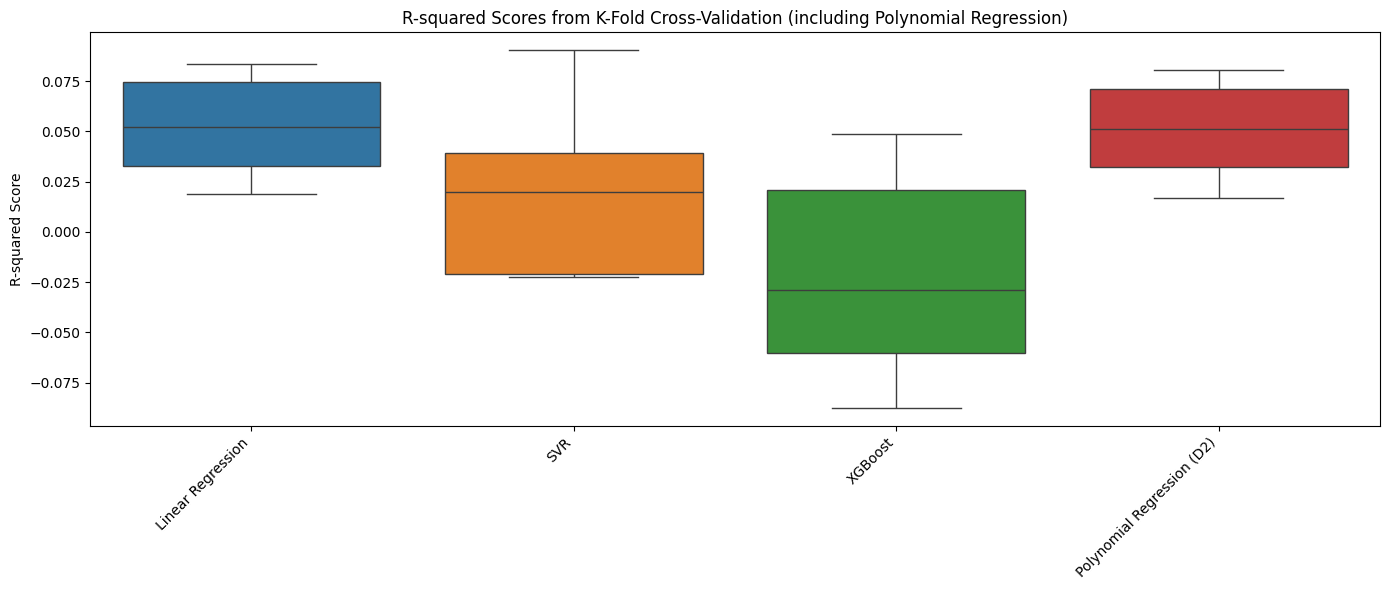

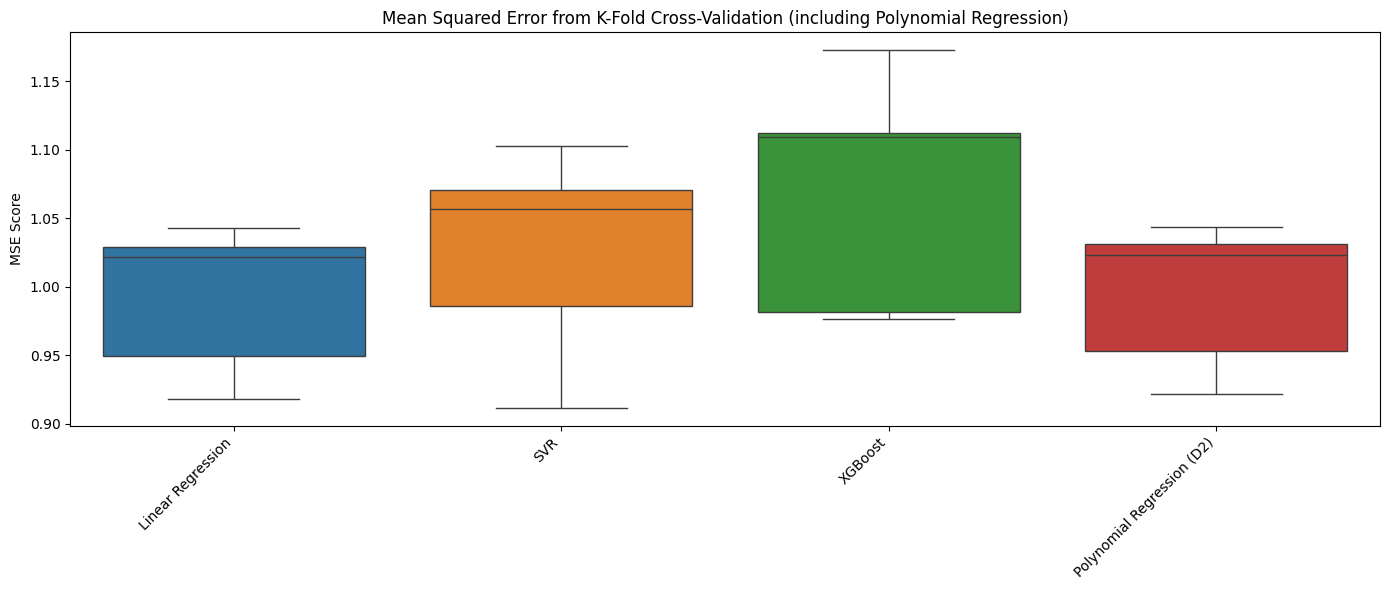

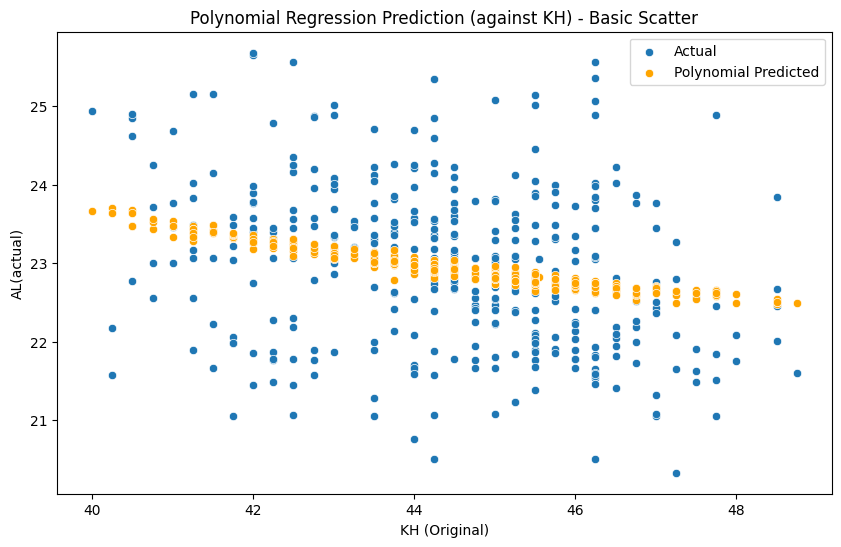

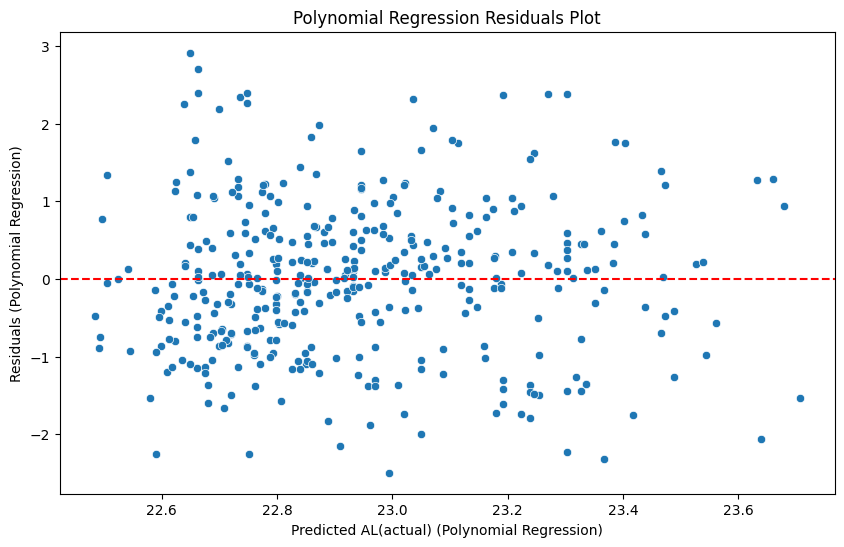


--- Statsmodels OLS Summary (Polynomial Regression Degree 2) ---
                            OLS Regression Results                            
Dep. Variable:             AL(actual)   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     18.14
Date:                Wed, 02 Jul 2025   Prob (F-statistic):           1.60e-17
Time:                        14:28:02   Log-Likelihood:                -2200.8
No. Observations:                1553   AIC:                             4414.
Df Residuals:                    1547   BIC:                             4446.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [ ]:
# prompt: Polynomials

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features
# degree=2 means creating features like KH^2, KV^2, KH*KV
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Get the names of the polynomial features
poly_feature_names = poly.get_feature_names_out(input_features=X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names, index=X.index)

# Split the polynomial features data into training and testing sets
X_poly_train, X_poly_test, y_train_poly, y_test_poly = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

# Scale the polynomial features
scaler_poly = StandardScaler()
X_poly_train_scaled = scaler_poly.fit_transform(X_poly_train)
X_poly_test_scaled = scaler_poly.transform(X_poly_test)

# Train a Linear Regression model on the polynomial features (Polynomial Regression)
poly_model = LinearRegression()
poly_model.fit(X_poly_train_scaled, y_train_poly)

# Make predictions
y_pred_poly = poly_model.predict(X_poly_test_scaled)

# Evaluate the Polynomial Regression model
mse_poly = mean_squared_error(y_test_poly, y_pred_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print("\n--- Polynomial Regression (Degree 2) Evaluation ---")
print(f"Mean Squared Error (Polynomial Regression): {mse_poly}")
print(f"R-squared (Polynomial Regression): {r2_poly}")

# Display the model coefficients and intercept for polynomial features
# Note: These coefficients correspond to the *scaled* polynomial features
print(f"Coefficients (Polynomial Regression): {poly_model.coef_}")
print(f"Intercept (Polynomial Regression): {poly_model.intercept_}")
print(f"Polynomial Feature Names: {poly_feature_names}")

# --- Cross-Validation for Polynomial Regression ---
print("\n--- Polynomial Regression Cross-Validation ---")

# Scale the full polynomial feature set for cross-validation
X_poly_scaled = scaler_poly.fit_transform(X_poly_df)

poly_scores_mse = -cross_val_score(LinearRegression(), X_poly_scaled, y, cv=kf, scoring='neg_mean_squared_error')
poly_scores_r2 = cross_val_score(LinearRegression(), X_poly_scaled, y, cv=kf, scoring='r2')

print(f"Mean MSE (Polynomial Regression CV): {poly_scores_mse.mean():.4f} (+/- {poly_scores_mse.std():.4f})")
print(f"Mean R-squared (Polynomial Regression CV): {poly_scores_r2.mean():.4f} (+/- {poly_scores_r2.std():.4f})")


# --- Add Polynomial Regression to Model Comparison ---
print("\n--- Updated Model Comparison Summary (Mean CV Scores) ---")
print(f"Linear Regression:           MSE = {lr_scores_mse.mean():.4f}, R2 = {lr_scores_r2.mean():.4f}")
print(f"SVR:                       MSE = {svm_scores_mse.mean():.4f}, R2 = {svm_scores_r2.mean():.4f}")
print(f"XGBoost:                   MSE = {xgb_scores_mse.mean():.4f}, R2 = {xgb_scores_r2.mean():.4f}")
print(f"Polynomial Regression (D2):  MSE = {poly_scores_mse.mean():.4f}, R2 = {poly_scores_r2.mean():.4f}")

# Update boxplots to include Polynomial Regression
results_r2_updated = pd.DataFrame({
    'Linear Regression': lr_scores_r2,
    'SVR': svm_scores_r2,
    'XGBoost': xgb_scores_r2,
    'Polynomial Regression (D2)': poly_scores_r2
})

plt.figure(figsize=(14, 6))
sns.boxplot(data=results_r2_updated)
plt.title('R-squared Scores from K-Fold Cross-Validation (including Polynomial Regression)')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right') # Rotate x-labels for readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

results_mse_updated = pd.DataFrame({
    'Linear Regression': lr_scores_mse,
    'SVR': svm_scores_mse,
    'XGBoost': xgb_scores_mse,
    'Polynomial Regression (D2)': poly_scores_mse
})

plt.figure(figsize=(14, 6))
sns.boxplot(data=results_mse_updated)
plt.title('Mean Squared Error from K-Fold Cross-Validation (including Polynomial Regression)')
plt.ylabel('MSE Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Optional: Plotting the results for Polynomial Regression (against one original feature for visualization)
# This is harder to visualize accurately with multiple polynomial features.
# A 3D surface plot would be needed for two original features + polynomial terms.
# Let's plot against the original 'KH' values for a basic scatter plot,
# but understand this doesn't fully represent the higher-dimensional polynomial fit.
plt.figure(figsize=(10, 6))
# Need original test data 'KH' for plotting x-axis
sns.scatterplot(x=X_test['KH'], y=y_test_poly, label='Actual')
sns.scatterplot(x=X_test['KH'], y=y_pred_poly, color='orange', label='Polynomial Predicted') # Use scatter for prediction points
plt.title('Polynomial Regression Prediction (against KH) - Basic Scatter')
plt.xlabel('KH (Original)')
plt.ylabel('AL(actual)')
plt.legend()
plt.show()

# Plotting Polynomial Regression residuals
residuals_poly = y_test_poly - y_pred_poly
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_poly, y=residuals_poly)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Polynomial Regression Residuals Plot')
plt.xlabel('Predicted AL(actual) (Polynomial Regression)')
plt.ylabel('Residuals (Polynomial Regression)')
plt.show()

# You could also use statsmodels with polynomial features
X_poly_sm = sm.add_constant(X_poly_df)
X_poly_train_sm, X_poly_test_sm, y_train_poly, y_test_poly = train_test_split(X_poly_sm, y, test_size=0.2, random_state=42)


# Create and fit the OLS model using statsmodels on polynomial features
sm_poly_model = sm.OLS(y_train_poly, X_poly_train_sm)
results_poly = sm_poly_model.fit()

# Print the summary table for polynomial regression
print("\n--- Statsmodels OLS Summary (Polynomial Regression Degree 2) ---")
print(results_poly.summary())

# The statsmodels summary for polynomial features allows you to check the significance
# (p-values) of each polynomial term (constant, KH, KV, KH^2, KH*KV, KV^2).


--- PCA Analysis ---
Explained Variance Ratio per Component: [0.89669027 0.10330973]
Cumulative Explained Variance Ratio: [0.89669027 1.        ]


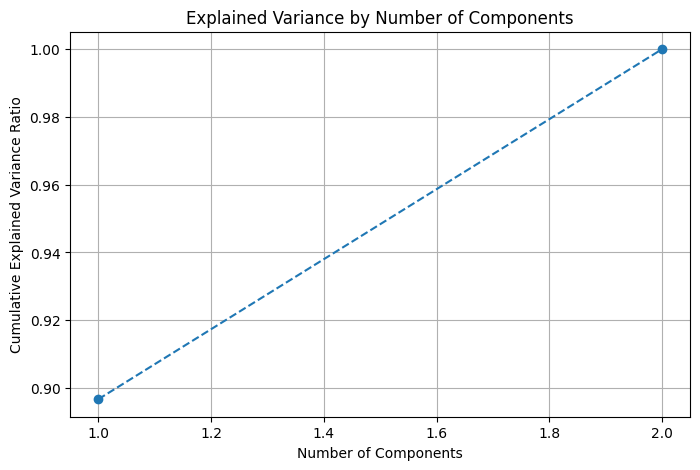


Shape of original scaled data: (1942, 2)
Shape after PCA (1 component): (1942, 1)

--- PCA (1 Component) + Linear Regression Evaluation ---
Mean Squared Error: 0.9542199296730064
R-squared: 0.0702384197827487

--- PCA (1 Component) + Linear Regression Cross-Validation ---
Mean MSE (PCA+LR CV): 0.9922 (+/- 0.0512)
Mean R-squared (PCA+LR CV): 0.0528 (+/- 0.0271)

--- Updated Model Comparison Summary (Mean CV Scores) ---
Linear Regression:           MSE = 0.9924, R2 = 0.0525
SVR:                       MSE = 1.0256, R2 = 0.0213
XGBoost:                   MSE = 1.0705, R2 = -0.0215
Polynomial Regression (D2):  MSE = 0.9947, R2 = 0.0504
PCA (1 Comp) + LR:         MSE = 0.9922, R2 = 0.0528


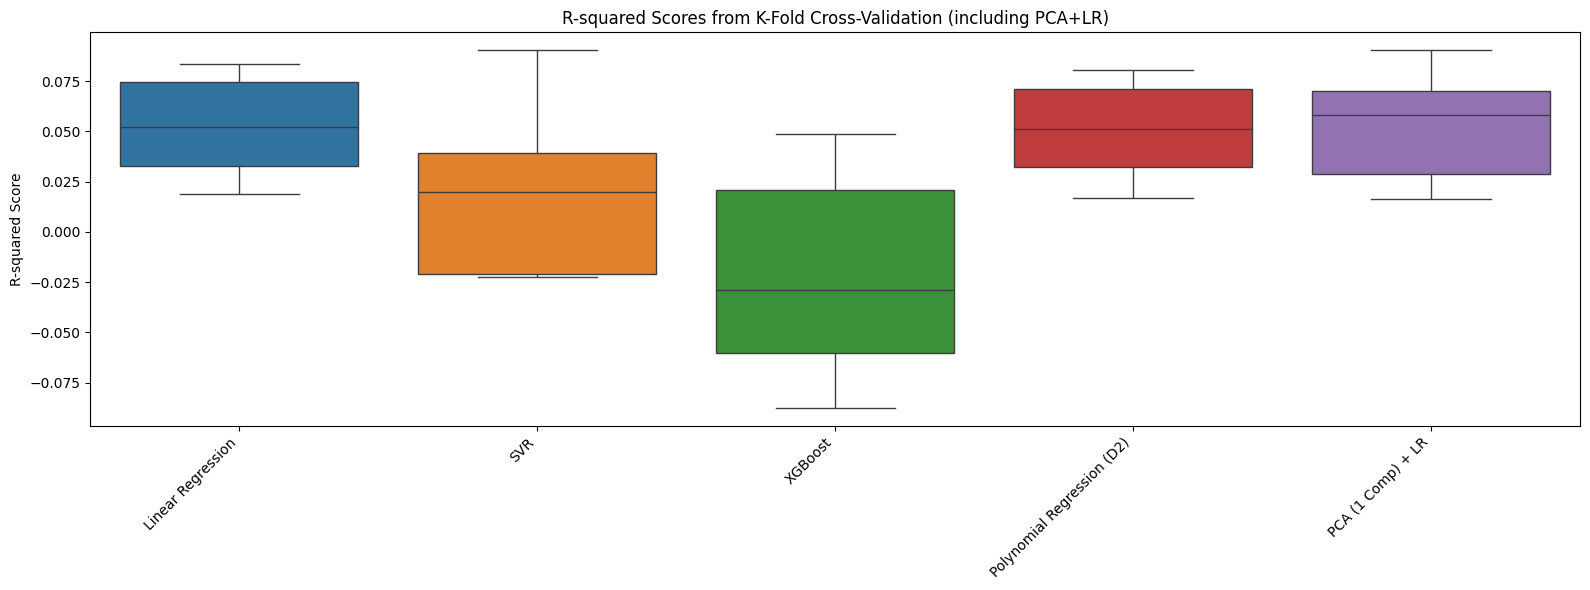

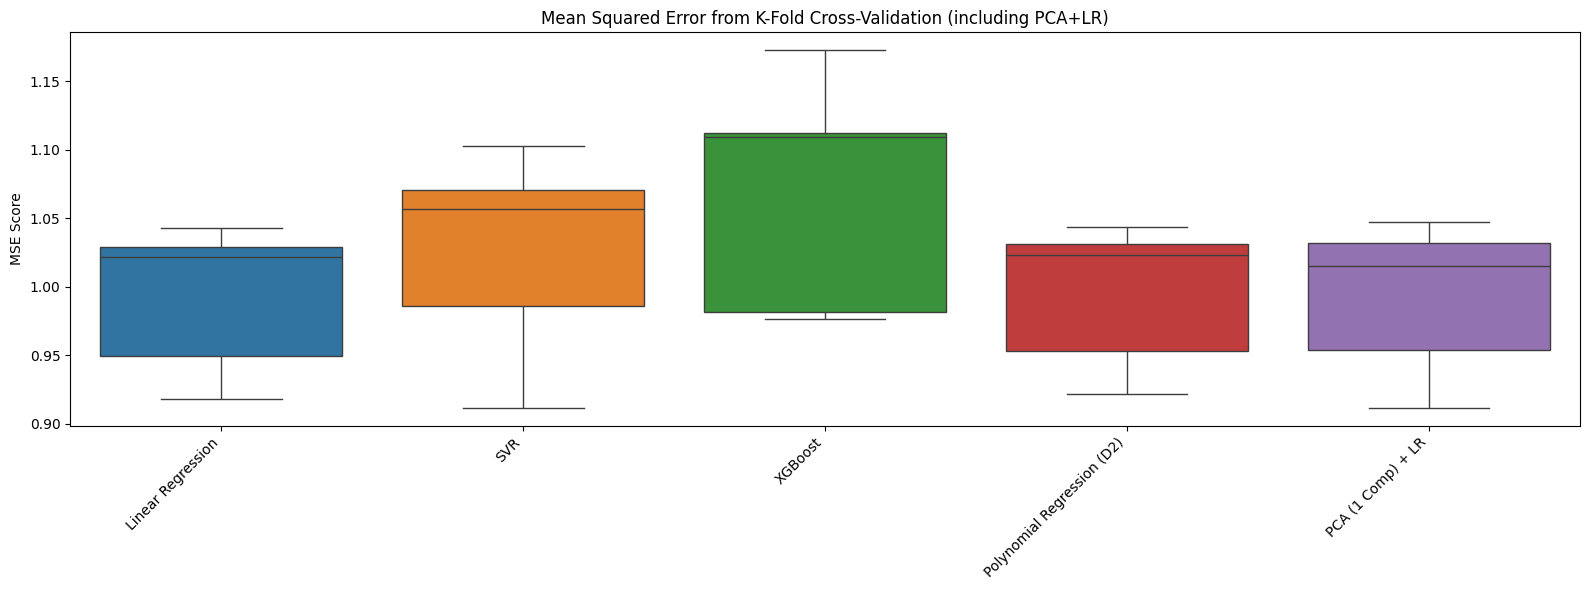

In [ ]:
# prompt: Pca

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Assuming X is your feature matrix (after scaling is a good practice for PCA)
# We already have X_scaled from the previous cross-validation step

# Perform PCA
# n_components can be an integer (number of components), or a float (variance ratio to keep)
pca = PCA(n_components=None) # Keep all components initially to analyze variance explained

# Fit PCA on the scaled features
pca.fit(X_scaled)

# Analyze the explained variance ratio of each component
print("\n--- PCA Analysis ---")
print("Explained Variance Ratio per Component:", pca.explained_variance_ratio_)
print("Cumulative Explained Variance Ratio:", np.cumsum(pca.explained_variance_ratio_))

# Visualize the explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, pca.n_components_ + 1), np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.grid(True)
plt.show()

# Decide on the number of components to keep based on the plot or a threshold (e.g., 95% variance)
# Since we only have 2 features, PCA will give at most 2 components.
# The first component will capture most of the variance.

# Let's transform the data using the number of components chosen
# For this 2-feature case, keeping 2 components just rotates the data.
# If we wanted to reduce dimensionality, we might choose n_components=1.
# Let's demonstrate with n_components=1 for dimensionality reduction
pca_reduced = PCA(n_components=1)
X_pca = pca_reduced.fit_transform(X_scaled)

print("\nShape of original scaled data:", X_scaled.shape)
print("Shape after PCA (1 component):", X_pca.shape)

# X_pca is now the transformed data with reduced dimensionality (if n_components < original features)

# You could then use X_pca as input for your regression models
# For example, training a Linear Regression model on the PCA-transformed data:

# Split the PCA data into training and testing sets
X_pca_train, X_pca_test, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Train a Linear Regression model on the PCA-transformed data
pca_lr_model = LinearRegression()
pca_lr_model.fit(X_pca_train, y_train_pca)

# Make predictions
y_pred_pca_lr = pca_lr_model.predict(X_pca_test)

# Evaluate the PCA + Linear Regression model
mse_pca_lr = mean_squared_error(y_test_pca, y_pred_pca_lr)
r2_pca_lr = r2_score(y_test_pca, y_pred_pca_lr)

print("\n--- PCA (1 Component) + Linear Regression Evaluation ---")
print(f"Mean Squared Error: {mse_pca_lr}")
print(f"R-squared: {r2_pca_lr}")

# Note: With only two original features, reducing to 1 component might lose significant information.
# PCA is generally more useful for datasets with a larger number of features where
# some features are highly correlated or contribute less to the total variance.

# You can also perform cross-validation with PCA followed by a model:
print("\n--- PCA (1 Component) + Linear Regression Cross-Validation ---")

# Create a pipeline that first applies PCA and then the Linear Regression model
from sklearn.pipeline import Pipeline

pipeline_pca_lr = Pipeline([
    ('pca', PCA(n_components=1)),
    ('linear_regression', LinearRegression())
])

# Evaluate the pipeline using cross-validation
pca_lr_scores_mse = -cross_val_score(pipeline_pca_lr, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
pca_lr_scores_r2 = cross_val_score(pipeline_pca_lr, X_scaled, y, cv=kf, scoring='r2')

print(f"Mean MSE (PCA+LR CV): {pca_lr_scores_mse.mean():.4f} (+/- {pca_lr_scores_mse.std():.4f})")
print(f"Mean R-squared (PCA+LR CV): {pca_lr_scores_r2.mean():.4f} (+/- {pca_lr_scores_r2.std():.4f})")

# Add PCA + LR to the model comparison summary
print("\n--- Updated Model Comparison Summary (Mean CV Scores) ---")
print(f"Linear Regression:           MSE = {lr_scores_mse.mean():.4f}, R2 = {lr_scores_r2.mean():.4f}")
print(f"SVR:                       MSE = {svm_scores_mse.mean():.4f}, R2 = {svm_scores_r2.mean():.4f}")
print(f"XGBoost:                   MSE = {xgb_scores_mse.mean():.4f}, R2 = {xgb_scores_r2.mean():.4f}")
print(f"Polynomial Regression (D2):  MSE = {poly_scores_mse.mean():.4f}, R2 = {poly_scores_r2.mean():.4f}")
print(f"PCA (1 Comp) + LR:         MSE = {pca_lr_scores_mse.mean():.4f}, R2 = {pca_lr_scores_r2.mean():.4f}")

# Update boxplots to include PCA + LR
results_r2_final = pd.DataFrame({
    'Linear Regression': lr_scores_r2,
    'SVR': svm_scores_r2,
    'XGBoost': xgb_scores_r2,
    'Polynomial Regression (D2)': poly_scores_r2,
    'PCA (1 Comp) + LR': pca_lr_scores_r2
})

plt.figure(figsize=(16, 6))
sns.boxplot(data=results_r2_final)
plt.title('R-squared Scores from K-Fold Cross-Validation (including PCA+LR)')
plt.ylabel('R-squared Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

results_mse_final = pd.DataFrame({
    'Linear Regression': lr_scores_mse,
    'SVR': svm_scores_mse,
    'XGBoost': xgb_scores_mse,
    'Polynomial Regression (D2)': poly_scores_mse,
    'PCA (1 Comp) + LR': pca_lr_scores_mse
})

plt.figure(figsize=(16, 6))
sns.boxplot(data=results_mse_final)
plt.title('Mean Squared Error from K-Fold Cross-Validation (including PCA+LR)')
plt.ylabel('MSE Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




--- Hyperparameter Tuning for SVR (GridSearchCV) ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters found for SVR: {'C': 0.1, 'epsilon': 0.2, 'gamma': 'scale'}
Best cross-validation MSE for SVR: 1.0119757961937348
Best SVR Model: SVR(C=0.1, epsilon=0.2)

--- Hyperparameter Tuning for XGBoost (GridSearchCV) ---
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best parameters found for XGBoost: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Best cross-validation MSE for XGBoost: 0.9950798295385974
Best XGBoost Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters found for SVR (RandomizedSearch): {'gamma': 'scale', 'epsilon': 0.2, 'C': 0.1}
Best cross-validation MSE for SVR (RandomizedSearch): 1.0119757961937348

--- Hyperparameter Tuning for XGBoost (RandomizedSearchCV) ---
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found for XGBoost (RandomizedSearch): {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best cross-validation MSE for XGBoost (RandomizedSearch): 0.9957977357175298

--- Evaluation of Best SVR Model on Test Set ---
Mean Squared Error (Best SVR): 0.9722681777814577
R-squared (Best SVR): 0.05265278028848963

--- Evaluation of Best XGBoost Model on Test Set ---
Mean Squared Error (Best XGBoost): 0.9530942874504097
R-squared (Best XGBoost): 0.07133520979844177

--- Final Model Comparison Summary (Test Set Evaluation) ---
Linear Regression:           MSE = 0.9496384668236305, R2 = 0.07470245161239408
SVR (Untuned):             MSE = 

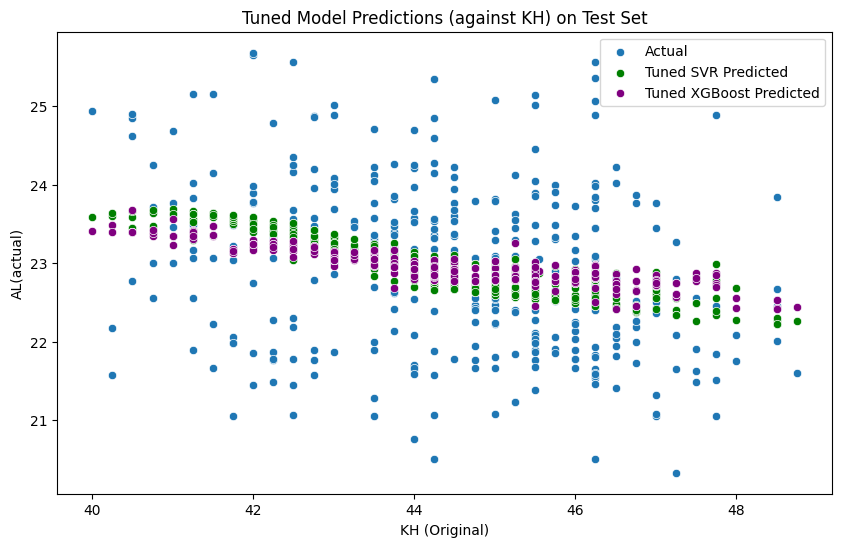

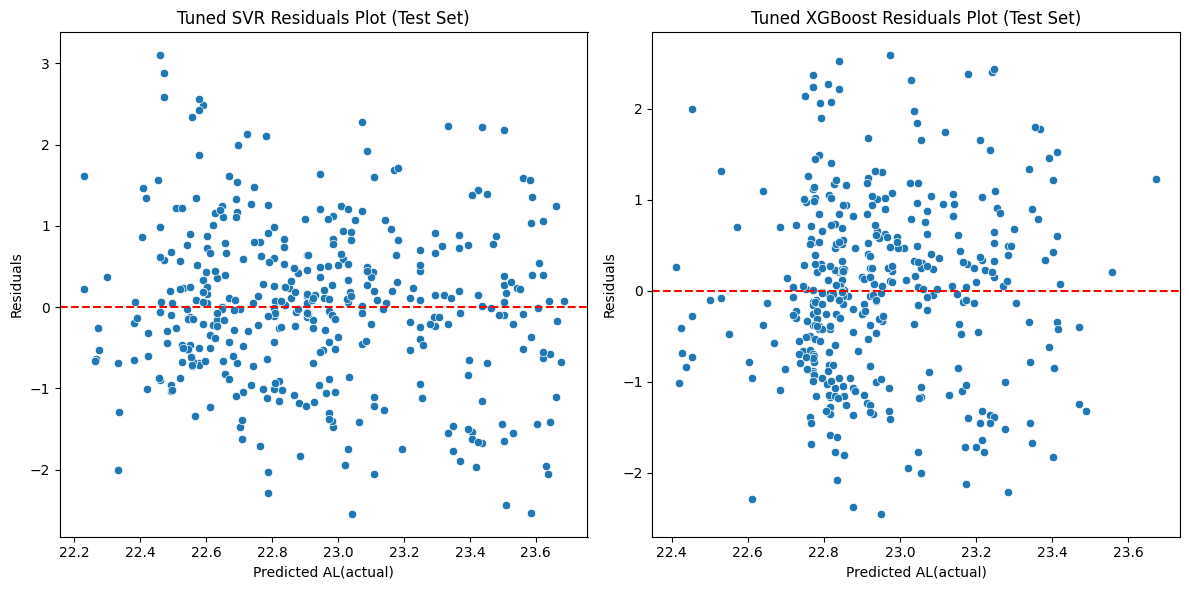

In [ ]:
# prompt: Hyper parametric tuning

import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# --- Hyperparameter Tuning ---

# Define parameter grids for the models you want to tune

# SVR Parameter Grid (Example parameters)
# C: Regularization parameter. The strength of the regularization is inversely proportional to C.
# epsilon: Epsilon in the epsilon-SVR model. It specifies the epsilon-tube within which no penalty is associated in the training loss function with points where the difference between the predicted and the actual value is less than epsilon.
# gamma: Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
param_grid_svr = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.001, 0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto'] # 'scale' uses 1 / (n_features * X.var()), 'auto' uses 1 / n_features
}

# XGBoost Parameter Grid (Example parameters)
# n_estimators: Number of boosting rounds.
# learning_rate: Step size shrinkage used in update to prevent overfitting.
# max_depth: Maximum depth of a tree.
# subsample: Fraction of samples used per tree.
# colsample_bytree: Fraction of features used per tree.
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Since Linear Regression and Polynomial Regression (with fixed degree) don't have many hyperparameters
# to tune in the same way as SVR or XGBoost, we typically tune these models by changing features (e.g., polynomial degree, interaction terms)
# or regularization (e.g., using Ridge or Lasso). We will focus on tuning SVR and XGBoost here.

# You need the scaled data for SVR and XGBoost tuning, as these models are sensitive to feature scaling.
# We already have X_scaled and y from previous steps.

# --- Hyperparameter Tuning for SVR using GridSearchCV ---
print("\n--- Hyperparameter Tuning for SVR (GridSearchCV) ---")

# Create a GridSearchCV object
# estimator: The model to tune (SVR in this case)
# param_grid: The dictionary with parameters and their values to try
# cv: The number of cross-validation folds (reusing the kf object)
# scoring: The metric to optimize ('neg_mean_squared_error' or 'r2')
# n_jobs: Number of CPU cores to use (-1 means all available)
grid_search_svr = GridSearchCV(estimator=SVR(kernel='rbf'),
                               param_grid=param_grid_svr,
                               cv=kf, # Use the same KFold object
                               scoring='neg_mean_squared_error', # Optimize for lowest MSE
                               n_jobs=-1,
                               verbose=1) # Print progress

# Fit GridSearchCV to the scaled data
# This will perform cross-validation for every combination of parameters in the grid
grid_search_svr.fit(X_scaled, y)

# Print the best parameters and the best score found
print("Best parameters found for SVR:", grid_search_svr.best_params_)
print("Best cross-validation MSE for SVR:", -grid_search_svr.best_score_) # Note the negative sign for neg_mean_squared_error

# Get the best trained model
best_svr_model = grid_search_svr.best_estimator_
print("Best SVR Model:", best_svr_model)

# --- Hyperparameter Tuning for XGBoost using GridSearchCV ---
print("\n--- Hyperparameter Tuning for XGBoost (GridSearchCV) ---")

grid_search_xgb = GridSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                               param_grid=param_grid_xgb,
                               cv=kf, # Use the same KFold object
                               scoring='neg_mean_squared_error', # Optimize for lowest MSE
                               n_jobs=-1,
                               verbose=1) # Print progress

# Fit GridSearchCV to the scaled data
grid_search_xgb.fit(X_scaled, y)

# Print the best parameters and the best score found
print("Best parameters found for XGBoost:", grid_search_xgb.best_params_)
print("Best cross-validation MSE for XGBoost:", -grid_search_xgb.best_score_)

# Get the best trained model
best_xgb_model = grid_search_xgb.best_estimator_
print("Best XGBoost Model:", best_xgb_model)


# --- Optional: Hyperparameter Tuning using RandomizedSearchCV ---
# RandomizedSearchCV is useful when the parameter grid is very large.
# It samples a fixed number of parameter combinations from the grid.

# Define parameter distributions (similar to grid but can include distributions)
# You might use scipy.stats for distributions if needed.
# For simplicity, let's use the same parameter ranges as for GridSearchCV.
param_dist_svr = param_grid_svr # Can use the same grid for sampling
param_dist_xgb = param_grid_xgb

print("\n--- Hyperparameter Tuning for SVR (RandomizedSearchCV) ---")

# Create a RandomizedSearchCV object
# n_iter: Number of parameter settings that are sampled.
#           Higher n_iter gives better chance of finding good parameters, but longer runtime.
random_search_svr = RandomizedSearchCV(estimator=SVR(kernel='rbf'),
                                     param_distributions=param_dist_svr,
                                     n_iter=50, # Number of combinations to sample (adjust based on grid size and time)
                                     cv=kf,
                                     scoring='neg_mean_squared_error',
                                     random_state=42, # For reproducibility
                                     n_jobs=-1,
                                     verbose=1)

random_search_svr.fit(X_scaled, y)

print("Best parameters found for SVR (RandomizedSearch):", random_search_svr.best_params_)
print("Best cross-validation MSE for SVR (RandomizedSearch):", -random_search_svr.best_score_)

print("\n--- Hyperparameter Tuning for XGBoost (RandomizedSearchCV) ---")

random_search_xgb = RandomizedSearchCV(estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
                                     param_distributions=param_dist_xgb,
                                     n_iter=50, # Number of combinations to sample (adjust based on grid size and time)
                                     cv=kf,
                                     scoring='neg_mean_squared_error',
                                     random_state=42, # For reproducibility
                                     n_jobs=-1,
                                     verbose=1)

random_search_xgb.fit(X_scaled, y)

print("Best parameters found for XGBoost (RandomizedSearch):", random_search_xgb.best_params_)
print("Best cross-validation MSE for XGBoost (RandomizedSearch):", -random_search_xgb.best_score_)

# --- Evaluate Best Models on the Test Set ---
# Now that you have the best parameters, you can train the models with these parameters
# on the full training data (X_train_scaled, y_train) and evaluate on the test data (X_test_scaled, y_test).
# Remember to scale X_train and X_test separately AFTER the split to avoid data leakage.

# Split the scaled data into training and testing sets (re-doing split for clarity)
X_train_scaled, X_test_scaled, y_train_tuned, y_test_tuned = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Train and evaluate the best SVR model on the test set
print("\n--- Evaluation of Best SVR Model on Test Set ---")
best_svr_model_final = SVR(**grid_search_svr.best_params_) # Instantiate with best parameters
best_svr_model_final.fit(X_train_scaled, y_train_tuned)
y_pred_best_svr = best_svr_model_final.predict(X_test_scaled)
mse_best_svr = mean_squared_error(y_test_tuned, y_pred_best_svr)
r2_best_svr = r2_score(y_test_tuned, y_pred_best_svr)
print(f"Mean Squared Error (Best SVR): {mse_best_svr}")
print(f"R-squared (Best SVR): {r2_best_svr}")

# Train and evaluate the best XGBoost model on the test set
print("\n--- Evaluation of Best XGBoost Model on Test Set ---")
best_xgb_model_final = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **grid_search_xgb.best_params_)
best_xgb_model_final.fit(X_train_scaled, y_train_tuned)
y_pred_best_xgb = best_xgb_model_final.predict(X_test_scaled)
mse_best_xgb = mean_squared_error(y_test_tuned, y_pred_best_xgb)
r2_best_xgb = r2_score(y_test_tuned, y_pred_best_xgb)
print(f"Mean Squared Error (Best XGBoost): {mse_best_xgb}")
print(f"R-squared (Best XGBoost): {r2_best_xgb}")

# Compare these test set results with the original models' test set results
# and the CV results. The tuned models should ideally perform better or more robustly.

# Final Model Comparison including Tuned Models (based on test set performance)
print("\n--- Final Model Comparison Summary (Test Set Evaluation) ---")
print(f"Linear Regression:           MSE = {mse}, R2 = {r2}")
print(f"SVR (Untuned):             MSE = {mse_svm}, R2 = {r2_svm}")
print(f"XGBoost (Untuned):         MSE = {mse_xgb}, R2 = {r2_xgb}")
print(f"Polynomial Regression (D2):  MSE = {mse_poly}, R2 = {r2_poly}")
print(f"PCA (1 Comp) + LR:         MSE = {mse_pca_lr}, R2 = {r2_pca_lr}")
print(f"SVR (Tuned):               MSE = {mse_best_svr}, R2 = {r2_best_svr}")
print(f"XGBoost (Tuned):           MSE = {mse_best_xgb}, R2 = {r2_best_xgb}")

# Note: Test set performance is a single snapshot. Cross-validation mean/std provide a
# better estimate of generalization performance. However, comparing final models on the
# same hold-out test set is also a standard practice.

# Visualize performance of best tuned models on the test set (against one feature)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['KH'], y=y_test_tuned, label='Actual')
sns.scatterplot(x=X_test['KH'], y=y_pred_best_svr, color='green', label='Tuned SVR Predicted')
sns.scatterplot(x=X_test['KH'], y=y_pred_best_xgb, color='purple', label='Tuned XGBoost Predicted')
plt.title('Tuned Model Predictions (against KH) on Test Set')
plt.xlabel('KH (Original)')
plt.ylabel('AL(actual)')
plt.legend()
plt.show()

# Visualize residuals of tuned models on the test set
residuals_best_svr = y_test_tuned - y_pred_best_svr
residuals_best_xgb = y_test_tuned - y_pred_best_xgb

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(x=y_pred_best_svr, y=residuals_best_svr)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Tuned SVR Residuals Plot (Test Set)')
plt.xlabel('Predicted AL(actual)')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(x=y_pred_best_xgb, y=residuals_best_xgb)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Tuned XGBoost Residuals Plot (Test Set)')
plt.xlabel('Predicted AL(actual)')
plt.ylabel('Residuals')

plt.tight_layout()
plt.show()


In [ ]:
df1=pd.read_excel('/content/Dr Kalyani thesis training Dataset KH KV AL ACD LT.xlsx')

In [ ]:
df1.shape

(503, 8)

In [ ]:
df1.columns

Index(['AGE ', 'SEX', 'KH', 'KV', 'AXIS', 'AL', 'ACD', 'LT'], dtype='object')

<Axes: >

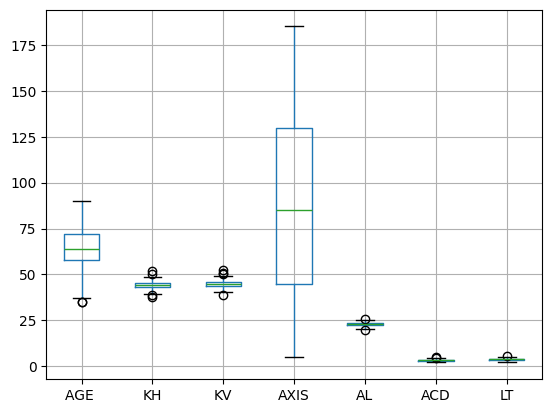

In [ ]:
df1.boxplot()

Original shape of df1: (503, 8)
Shape after removing outliers in 'AL': (501, 8) (2 rows removed)
Shape after removing outliers in 'KH': (497, 8) (4 rows removed)
Shape after removing outliers in 'KV': (496, 8) (1 rows removed)
Shape after removing outliers in 'ACD': (494, 8) (2 rows removed)
Shape after removing outliers in 'LT': (493, 8) (1 rows removed)

Final shape of df1 after removing outliers from specified columns: (493, 8)


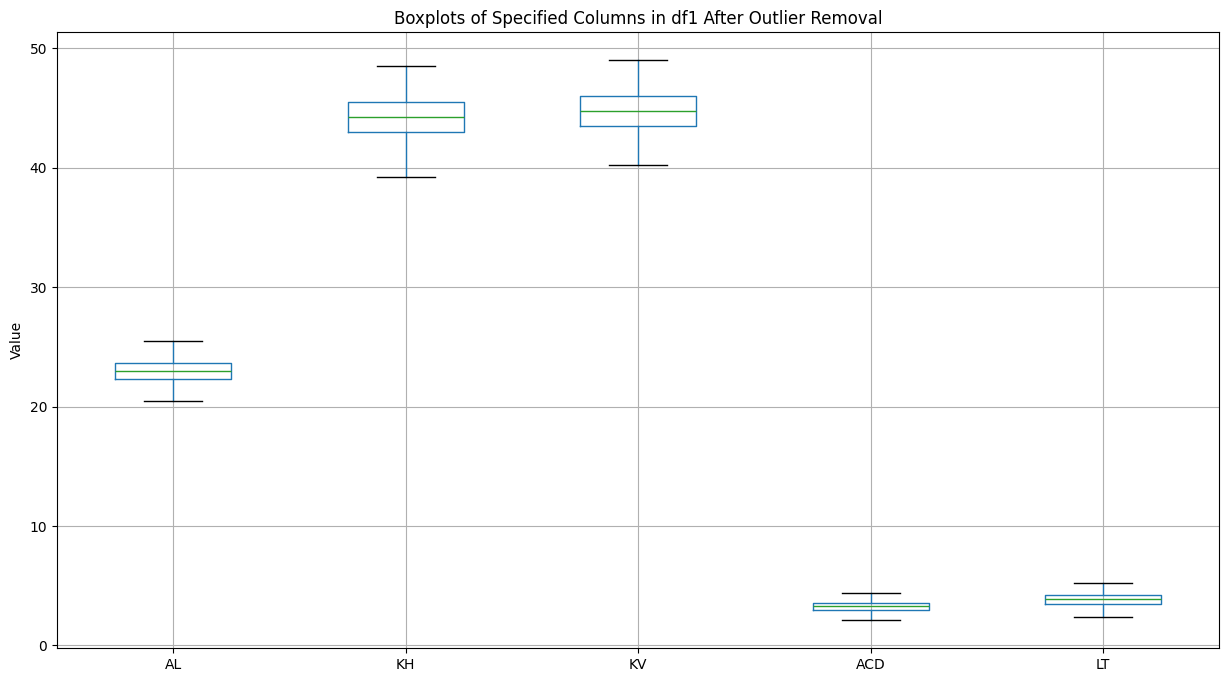

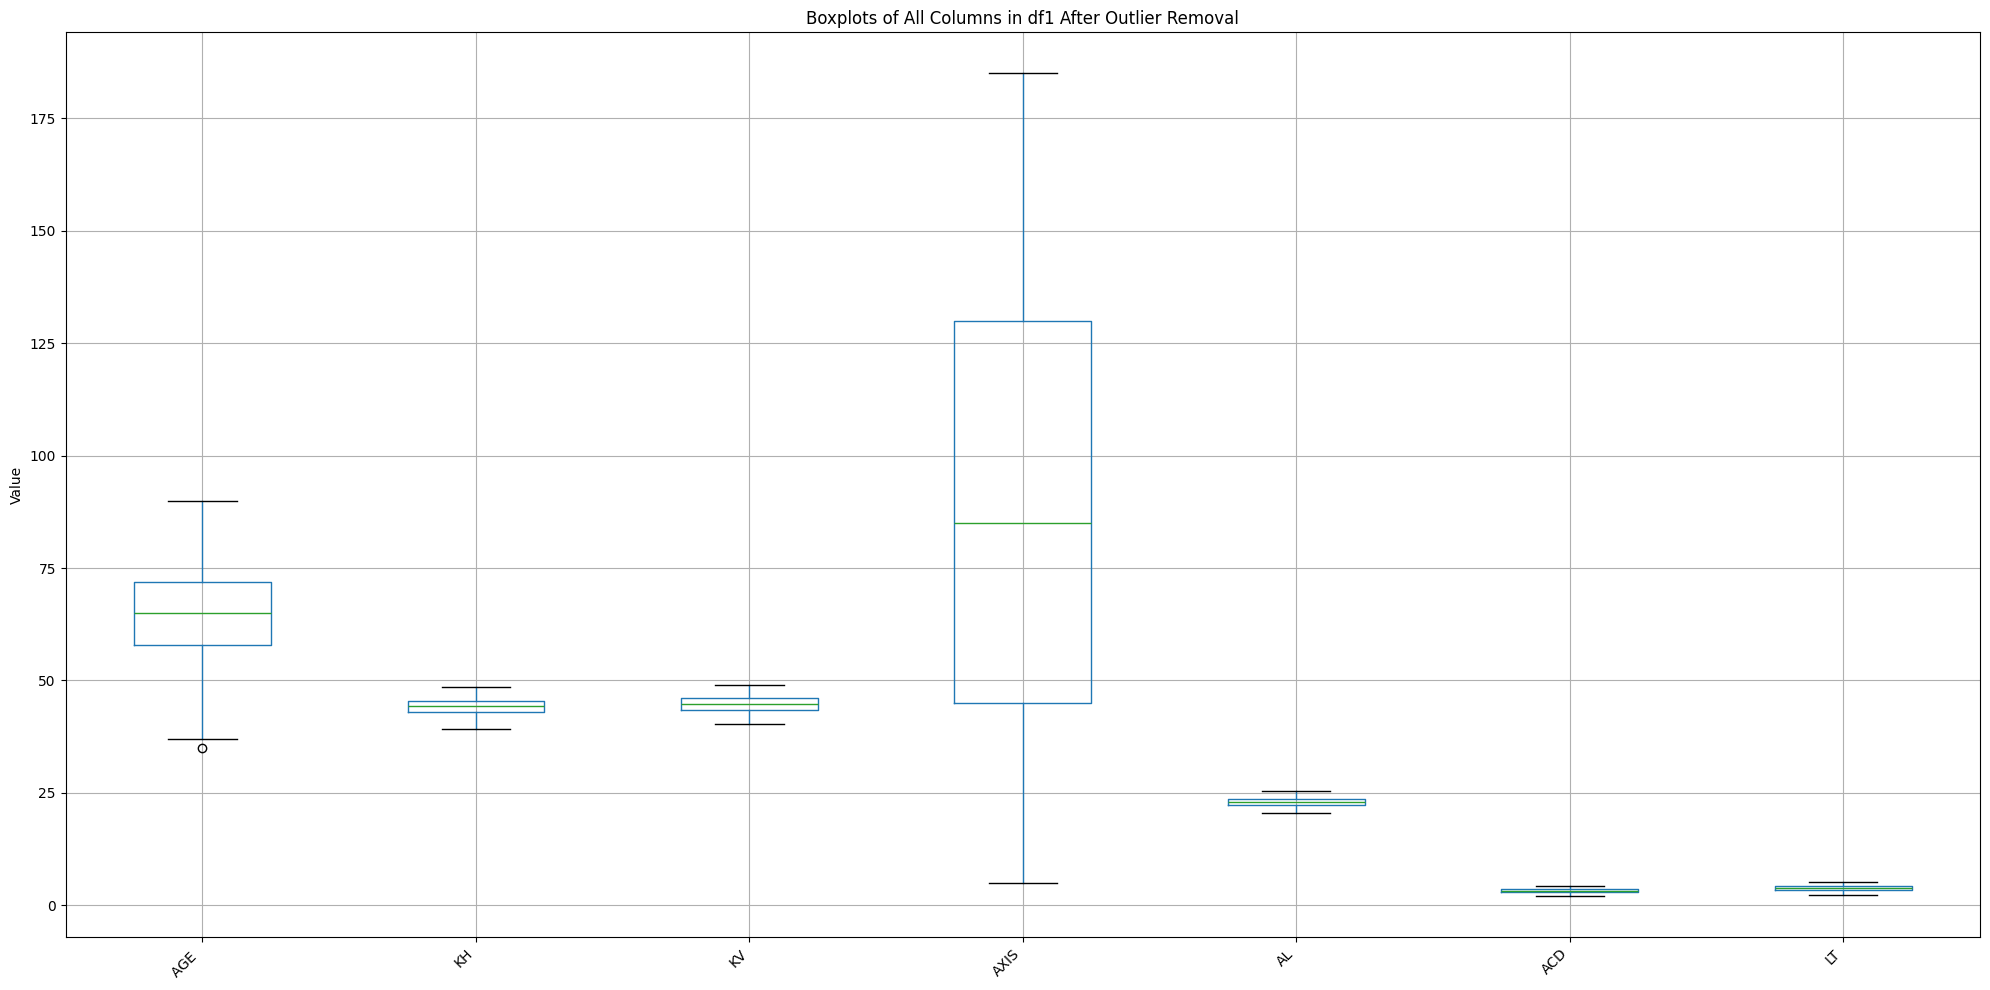

In [ ]:
# prompt: Remove outliers in AL, KH, KV, ACD,LT i n df1

import matplotlib.pyplot as plt
def remove_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)].copy()
  return df_cleaned

# List of columns to remove outliers from in df1
columns_to_clean_df1 = ['AL', 'KH', 'KV', 'ACD', 'LT']

df1_cleaned = df1.copy()

print("Original shape of df1:", df1_cleaned.shape)

for col in columns_to_clean_df1:
  if col in df1_cleaned.columns:
    initial_shape = df1_cleaned.shape
    df1_cleaned = remove_outliers_iqr(df1_cleaned, col)
    print(f"Shape after removing outliers in '{col}': {df1_cleaned.shape} ({initial_shape[0] - df1_cleaned.shape[0]} rows removed)")
  else:
    print(f"Warning: Column '{col}' not found in df1.")

print("\nFinal shape of df1 after removing outliers from specified columns:", df1_cleaned.shape)

# Display boxplots of the cleaned df1 to visually check outlier removal
plt.figure(figsize=(15, 8))
df1_cleaned[columns_to_clean_df1].boxplot()
plt.title('Boxplots of Specified Columns in df1 After Outlier Removal')
plt.ylabel('Value')
plt.show()

# Display boxplots of all columns in the cleaned df1
plt.figure(figsize=(20, 10))
df1_cleaned.boxplot()
plt.title('Boxplots of All Columns in df1 After Outlier Removal')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



--- Correlation Matrix for KH, KV, AL, ACD, LT in df1_cleaned ---
           KH        KV        AL       ACD        LT
KH   1.000000  0.916537 -0.730096 -0.421650  0.383393
KV   0.916537  1.000000 -0.727491 -0.429029  0.390805
AL  -0.730096 -0.727491  1.000000  0.461365 -0.428914
ACD -0.421650 -0.429029  0.461365  1.000000 -0.450623
LT   0.383393  0.390805 -0.428914 -0.450623  1.000000


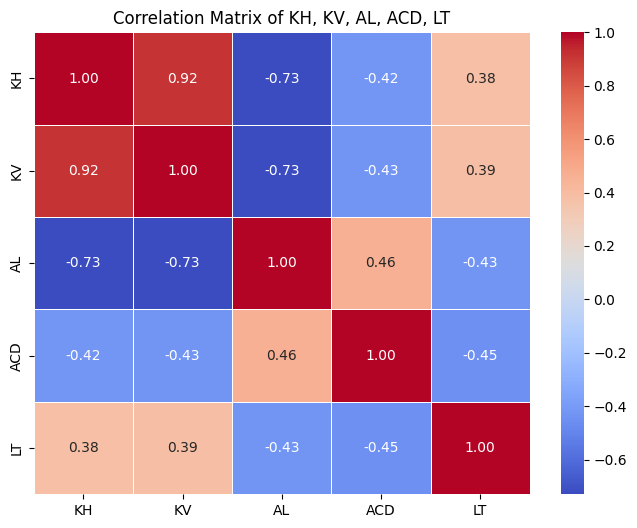

In [ ]:
# prompt: Correlate KH, KV, AL, ACD, LT

import matplotlib.pyplot as plt
# Correlate the specified columns in df1_cleaned
correlation_matrix_df1 = df1_cleaned[['KH', 'KV', 'AL', 'ACD', 'LT']].corr()

print("\n--- Correlation Matrix for KH, KV, AL, ACD, LT in df1_cleaned ---")
print(correlation_matrix_df1)

# Optional: Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_df1, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of KH, KV, AL, ACD, LT')
plt.show()



--- Linear Regression on df1_cleaned (X=KH, KV, Y=AL) ---
Mean Squared Error: 0.5406065587281697
R-squared: 0.4932000246074124
Coefficients: [-0.22752903 -0.20139731]
Intercept: 42.075237799917375


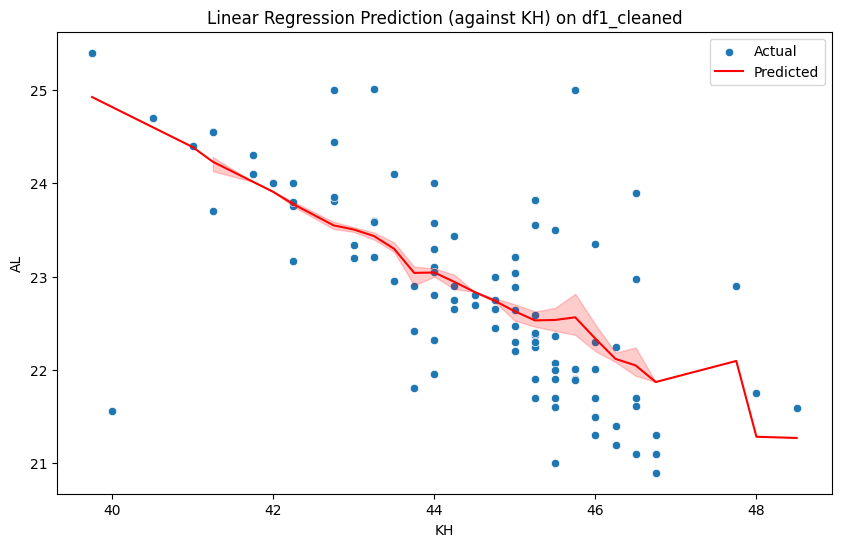

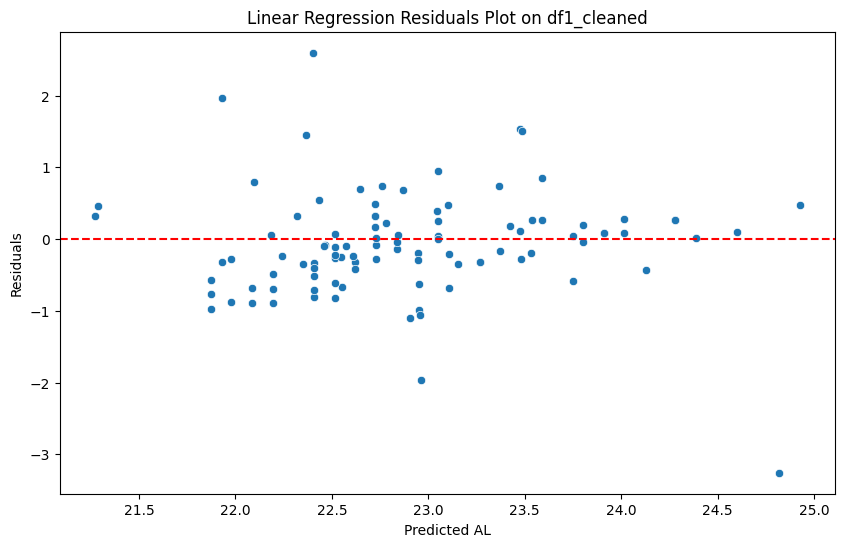


--- SVR Model on df1_cleaned (X=KH, KV, Y=AL) ---
Mean Squared Error (SVR): 0.538038737356564
R-squared (SVR): 0.49560726844663594


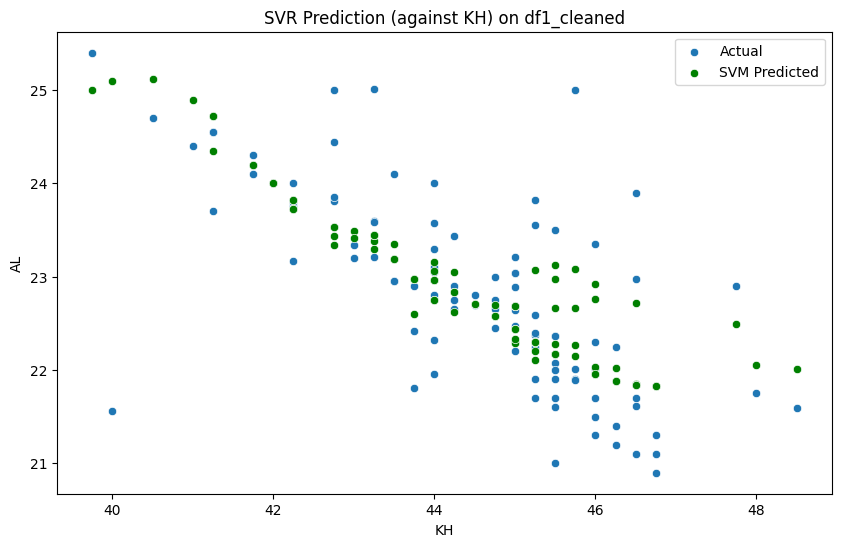

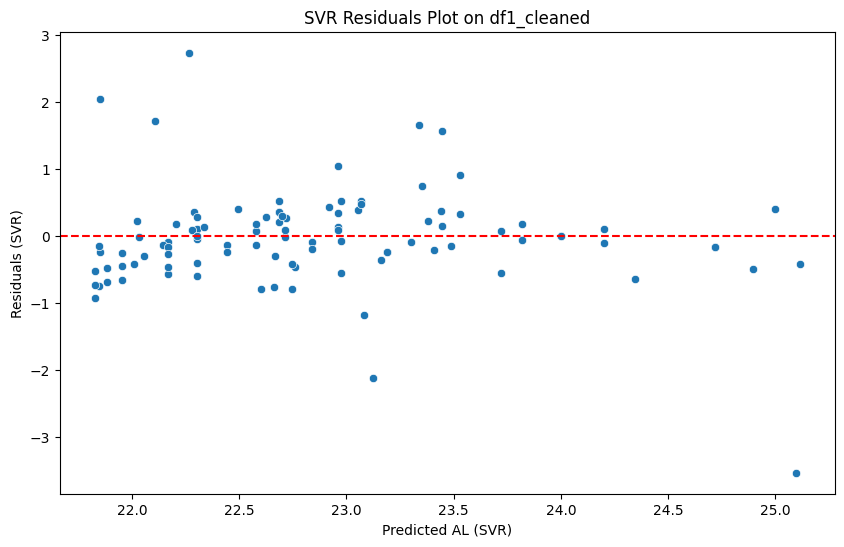


--- XGBoost Model on df1_cleaned (X=KH, KV, Y=AL) ---
Mean Squared Error (XGBoost): 0.6952007805439078
R-squared (XGBoost): 0.34827328158680504


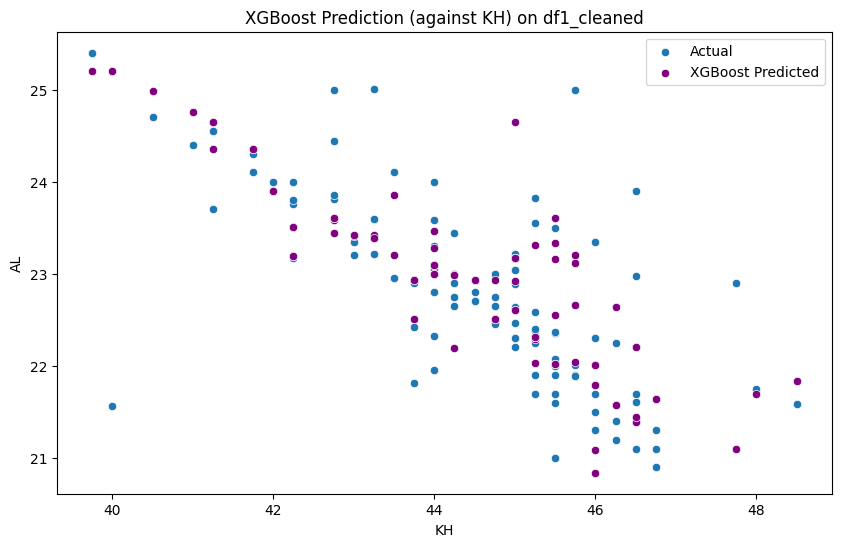

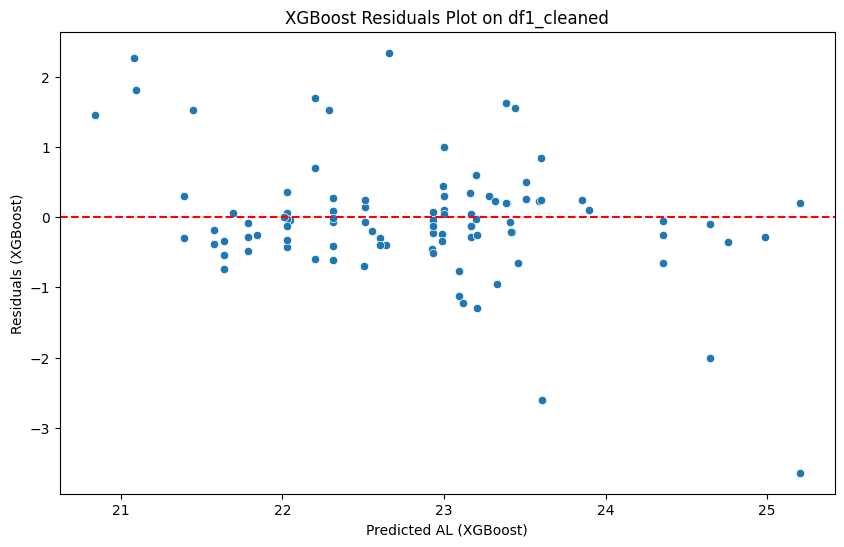


--- Model Comparison Summary on df1_cleaned (Test Set Evaluation) ---
Linear Regression: MSE = 0.5406, R2 = 0.4932
SVR:               MSE = 0.5380, R2 = 0.4956
XGBoost:           MSE = 0.6952, R2 = 0.3483


In [ ]:
# prompt: X KH, KV. Y as AL

import matplotlib.pyplot as plt
# Redefine features (X) and target (y) for df1_cleaned based on the task requirement (X=KH, KV, Y=AL)
X1 = df1_cleaned[['KH', 'KV']]
y1 = df1_cleaned['AL'] # 'AL' is the target column in df1

# Split data into training and testing sets for df1
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

# --- Linear Regression Model on df1_cleaned ---
print("\n--- Linear Regression on df1_cleaned (X=KH, KV, Y=AL) ---")

# Create a Linear Regression model
model1_lr = LinearRegression()

# Train the model
model1_lr.fit(X1_train, y1_train)

# Make predictions
y1_pred_lr = model1_lr.predict(X1_test)

# Evaluate the model
mse1_lr = mean_squared_error(y1_test, y1_pred_lr)
r21_lr = r2_score(y1_test, y1_pred_lr)

print(f"Mean Squared Error: {mse1_lr}")
print(f"R-squared: {r21_lr}")

# Display the model coefficients and intercept
print(f"Coefficients: {model1_lr.coef_}")
print(f"Intercept: {model1_lr.intercept_}")

# Optional: Plotting the results (against one feature for visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X1_test['KH'], y=y1_test, label='Actual')
sns.lineplot(x=X1_test['KH'], y=y1_pred_lr, color='red', label='Predicted')
plt.title('Linear Regression Prediction (against KH) on df1_cleaned')
plt.xlabel('KH')
plt.ylabel('AL')
plt.legend()
plt.show()

# Plotting residuals
residuals1_lr = y1_test - y1_pred_lr
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y1_pred_lr, y=residuals1_lr)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Linear Regression Residuals Plot on df1_cleaned')
plt.xlabel('Predicted AL')
plt.ylabel('Residuals')
plt.show()

# --- SVR Model on df1_cleaned ---
print("\n--- SVR Model on df1_cleaned (X=KH, KV, Y=AL) ---")

# Scale the features for SVR
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Create an SVR model (using default rbf kernel for now, can tune later)
model1_svm = SVR(kernel='rbf')

# Train the SVR model
model1_svm.fit(X1_train_scaled, y1_train)

# Make predictions using the SVR model
y1_pred_svm = model1_svm.predict(X1_test_scaled)

# Evaluate the SVR model
mse1_svm = mean_squared_error(y1_test, y1_pred_svm)
r21_svm = r2_score(y1_test, y1_pred_svm)

print(f"Mean Squared Error (SVR): {mse1_svm}")
print(f"R-squared (SVR): {r21_svm}")

# Plotting SVR results (against original KH for visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X1_test['KH'], y=y1_test, label='Actual')
sns.scatterplot(x=X1_test['KH'], y=y1_pred_svm, color='green', label='SVM Predicted')
plt.title('SVR Prediction (against KH) on df1_cleaned')
plt.xlabel('KH')
plt.ylabel('AL')
plt.legend()
plt.show()

# Plotting SVR residuals
residuals1_svm = y1_test - y1_pred_svm
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y1_pred_svm, y=residuals1_svm)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('SVR Residuals Plot on df1_cleaned')
plt.xlabel('Predicted AL (SVR)')
plt.ylabel('Residuals (SVR)')
plt.show()

# --- XGBoost Model on df1_cleaned ---
print("\n--- XGBoost Model on df1_cleaned (X=KH, KV, Y=AL) ---")

# Create an XGBoost Regressor model (using default/basic parameters for now)
model1_xgb = xgb.XGBRegressor(objective='reg:squarederror',
                             n_estimators=100,
                             learning_rate=0.1,
                             max_depth=5,
                             random_state=42)

# Train the XGBoost model on the scaled data (XGBoost is less sensitive but scaling is good practice)
model1_xgb.fit(X1_train_scaled, y1_train) # Use scaled data if you used it for other models

# Make predictions using the XGBoost model
y1_pred_xgb = model1_xgb.predict(X1_test_scaled)

# Evaluate the XGBoost model
mse1_xgb = mean_squared_error(y1_test, y1_pred_xgb)
r21_xgb = r2_score(y1_test, y1_pred_xgb)

print(f"Mean Squared Error (XGBoost): {mse1_xgb}")
print(f"R-squared (XGBoost): {r21_xgb}")

# Plotting XGBoost results (against original KH for visualization)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X1_test['KH'], y=y1_test, label='Actual')
sns.scatterplot(x=X1_test['KH'], y=y1_pred_xgb, color='purple', label='XGBoost Predicted')
plt.title('XGBoost Prediction (against KH) on df1_cleaned')
plt.xlabel('KH')
plt.ylabel('AL')
plt.legend()
plt.show()

# Plotting XGBoost residuals
residuals1_xgb = y1_test - y1_pred_xgb
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y1_pred_xgb, y=residuals1_xgb)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('XGBoost Residuals Plot on df1_cleaned')
plt.xlabel('Predicted AL (XGBoost)')
plt.ylabel('Residuals (XGBoost)')
plt.show()

# --- Model Comparison Summary on df1_cleaned (Test Set) ---
print("\n--- Model Comparison Summary on df1_cleaned (Test Set Evaluation) ---")
print(f"Linear Regression: MSE = {mse1_lr:.4f}, R2 = {r21_lr:.4f}")
print(f"SVR:               MSE = {mse1_svm:.4f}, R2 = {r21_svm:.4f}")
print(f"XGBoost:           MSE = {mse1_xgb:.4f}, R2 = {r21_xgb:.4f}")

# Further steps would include Cross-Validation and Hyperparameter tuning for df1_cleaned as done for df.
# Since the request is specifically for X=KH, KV and Y=AL from df1, the initial models are demonstrated above.